# Hand Detection CNN - Train From Scratch

This notebook:
1. Mounts Google Drive
2. Installs MediaPipe
3. Generates bounding-box labels with MediaPipe Hands (streaming, low RAM)
4. Builds a `tf.data` pipeline with augmentation
5. Defines a custom CNN from scratch
6. Trains with per-epoch checkpoints saved to Drive
7. Visualises predicted bounding boxes

> **Runtime -> Change runtime type -> T4 GPU** before running.

## Cell 1 - Mount Google Drive

In [ ]:
from google.colab import drive
# Standard Colab mount point: Drive root appears at /content/drive
# Your files will then be accessible at /content/drive/MyDrive/...
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

In [6]:
#the api which downloads a file which is used to detect hands
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task \
     -O /content/hand_landmarker.task

## Cell 2 - Install / upgrade dependencies

In [2]:
# MediaPipe 0.10.x ships with its own bundled protobuf; keep it isolated.
!pip install -q mediapipe opencv-python-headless
print('Dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.4 MB/s eta 0:00:00
Dependencies ready.


## Cell 3 - Imports & global constants

In [3]:
import os
import math
import random
import glob
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# -- Paths -----------------------------------------------------------------------
# Standard Colab Google Drive mount: /content/drive/MyDrive/<your folder>
DATASET_ROOT   = '/content/drive/MyDrive/ML-CEP/data'
CHECKPOINT_DIR = '/content/drive/MyDrive/ML-CEP/modelForHands'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# -- Image / model constants -----------------------------------------------------
IMG_SIZE   = 128          # images are resized to 128x128 during the tf.data pipeline
BATCH_SIZE = 16
EPOCHS     = 40
SEED       = 42

# Splits (must sum to 1)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# TEST_FRAC  = 0.15  (remainder)

tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow {tf.__version__}  |  MediaPipe {mp.__version__}')

TensorFlow 2.19.0  |  MediaPipe 0.10.32


## Cell 4 - Collect image paths from the dataset folder

Expected layout:
```
data/
  1/
    manahil/  sitwat/  Marium/  talha/
  2/ ...
  26/ ...
```

In [4]:
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def collect_image_paths(root: str) -> list:
    """Walk dataset root and return sorted list of image file paths."""
    paths = []
    root_path = Path(root)
    for main_folder in sorted(root_path.iterdir()):
        if not main_folder.is_dir():
            continue
        for sub_folder in sorted(main_folder.iterdir()):
            if not sub_folder.is_dir():
                continue
            for img_file in sorted(sub_folder.iterdir()):
                if img_file.suffix.lower() in VALID_EXTENSIONS:
                    paths.append(str(img_file))
    return paths


all_paths = collect_image_paths(DATASET_ROOT)
print(f'Total image files found: {len(all_paths)}')
if all_paths:
    print('Example:', all_paths[0])

Total image files found: 5540
Example: /content/drive/MyDrive/ML-CEP/data/1/Marium/66092.jpg


## Cell 5 - MediaPipe Hands label generator (streaming / low-RAM)

Processes one image at a time - never loads the full dataset into RAM.
Yields `(image_path, [x, y, w, h])` tuples where all values are **normalised to [0, 1]**.

In [9]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def get_hand_bbox_normalised(image_bgr: np.ndarray, hand_landmarker):
    """
    Run MediaPipe HandLandmarker (Tasks API) on a BGR image.
    Returns normalised (x, y, w, h) of the bounding box, or None if no hand found.
    x, y -> top-left corner  |  w, h -> width / height  (all in [0, 1])
    """
    # Tasks API requires RGB numpy array wrapped in mp.Image
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    result = hand_landmarker.detect(mp_image)

    if not result.hand_landmarks:
        return None

    # Use the first detected hand
    landmarks = result.hand_landmarks[0]
    xs = [lm.x for lm in landmarks]
    ys = [lm.y for lm in landmarks]

    # Clamp to [0, 1] in case landmarks go slightly out of bounds
    x_min = max(0.0, min(xs))
    y_min = max(0.0, min(ys))
    x_max = min(1.0, max(xs))
    y_max = min(1.0, max(ys))

    # Add a small padding (2% of image size) around the tight box
    pad = 0.1
    x_min = max(0.0, x_min - pad)
    y_min = max(0.0, y_min - pad)
    x_max = min(1.0, x_max + pad)
    y_max = min(1.0, y_max + pad)

    w = x_max - x_min
    h = y_max - y_min
    if w <= 0 or h <= 0:
        return None

    return [x_min, y_min, w, h]


def generate_labels(image_paths: list, verbose_every: int = 100):
    """
    Generator - yields (path_str, bbox_list) for every image where
    MediaPipe detects a hand.  Images with no detection are skipped.
    """
    BaseOptions = python.BaseOptions
    HandLandmarker = vision.HandLandmarker
    HandLandmarkerOptions = vision.HandLandmarkerOptions
    VisionRunningMode = vision.RunningMode

    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path='/content/hand_landmarker.task'),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.3
    )

    with HandLandmarker.create_from_options(options) as hand_landmarker:
        skipped = 0
        for idx, path in enumerate(image_paths):
            if verbose_every and idx % verbose_every == 0:
                print(f'  Processed {idx}/{len(image_paths)}, skipped so far: {skipped}')

            img = cv2.imread(str(path))
            if img is None:
                skipped += 1
                continue

            bbox = get_hand_bbox_normalised(img, hand_landmarker)
            if bbox is None:
                skipped += 1
                continue

            yield path, bbox

        print(f'Done. Total images: {len(image_paths)}, skipped (no hand): {skipped}')

print('Label generator defined.')

Label generator defined.


  Processed 0/16, skipped so far: 0
  Processed 5/16, skipped so far: 0
  Processed 10/16, skipped so far: 0
  Processed 15/16, skipped so far: 0


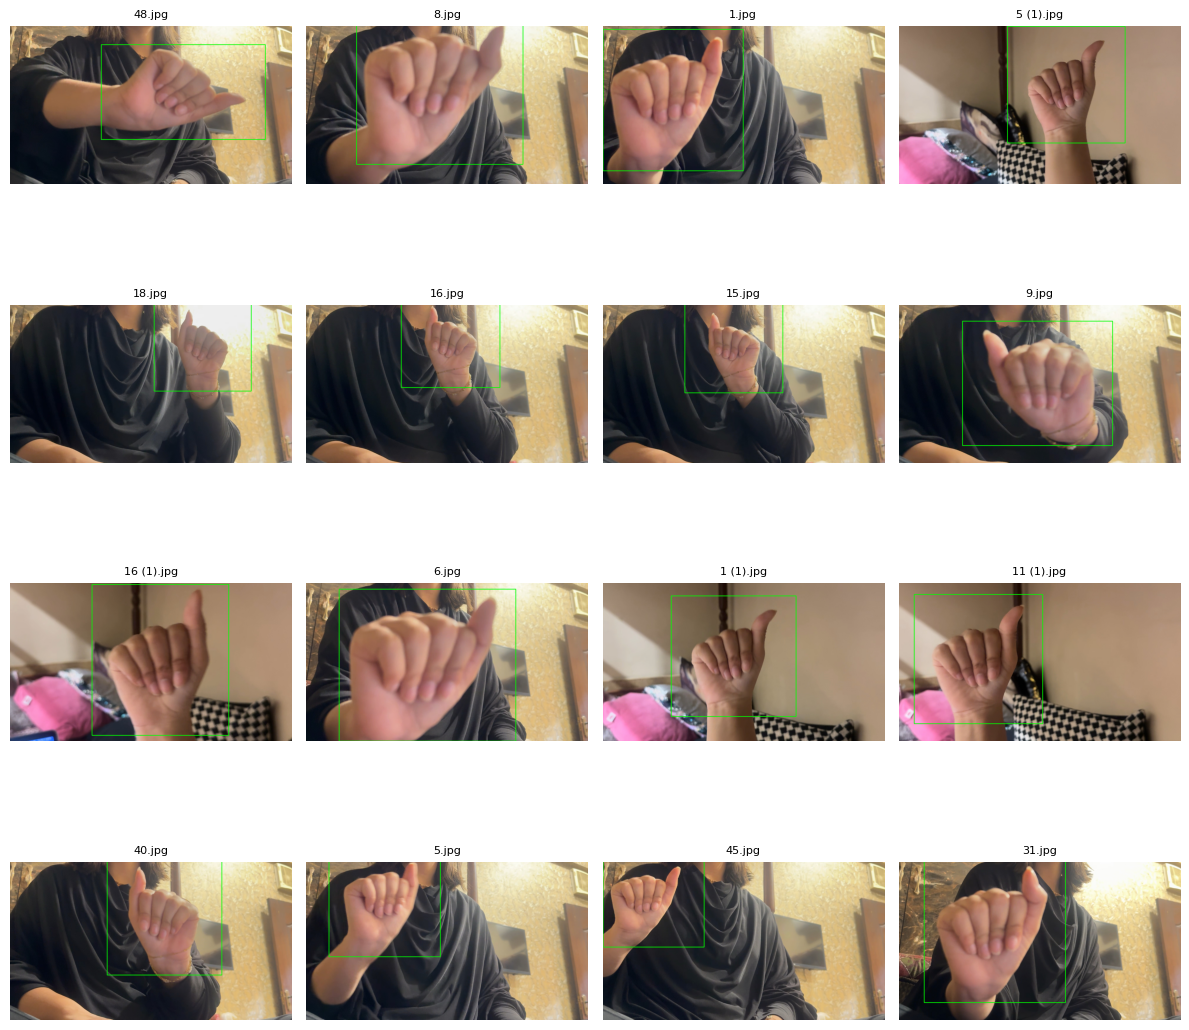

In [7]:
#### for test

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random

# Path to images
image_dir = Path('/content/drive/MyDrive/ML-CEP/data/1/manahil/')
image_paths = list(image_dir.glob('*.jpg'))  # or '*.png' if PNG

# Randomly pick 16 images
sample_paths = random.sample(image_paths, 16)

# Use your generator
gen = generate_labels(sample_paths, verbose_every=5)

# Prepare a 4x4 plot
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for ax in axes:
    try:
        path, bbox = next(gen)
    except StopIteration:
        break

    img = cv2.imread(str(path))
    if img is None:
        continue

    h, w, _ = img.shape
    x, y, bw, bh = bbox

    # Convert normalized bbox to pixels
    x1 = int(x * w)
    y1 = int(y * h)
    x2 = int((x + bw) * w)
    y2 = int((y + bh) * h)

    # Draw green rectangle
    img_box = img.copy()
    cv2.rectangle(img_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

    # Convert BGR to RGB for matplotlib
    img_box = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)

    ax.imshow(img_box)
    ax.set_title(path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 6 - Run MediaPipe over the full dataset and save a label file

Results are cached to a `.npz` file on Drive so you don't have to re-run MediaPipe after a session restart.

In [10]:
LABEL_CACHE = os.path.join(CHECKPOINT_DIR, 'labels_cache_data.npz')

if os.path.exists(LABEL_CACHE):
    print('Loading labels from cache ...')
    cache = np.load(LABEL_CACHE, allow_pickle=True)
    labelled_paths = list(cache['paths'])
    labelled_boxes = list(cache['boxes'])
    print(f'  Loaded {len(labelled_paths)} labelled samples from cache.')
else:
    print('Running MediaPipe Hands on dataset (this may take ~5-15 min) ...')
    labelled_paths = []
    labelled_boxes = []

    for p, bbox in generate_labels(all_paths):
        labelled_paths.append(p)
        labelled_boxes.append(bbox)

    # Save cache
    np.savez_compressed(
        LABEL_CACHE,
        paths=np.array(labelled_paths),
        boxes=np.array(labelled_boxes, dtype=np.float32)
    )
    print(f'Cache saved to {LABEL_CACHE}')

labelled_paths = np.array(labelled_paths)
labelled_boxes = np.array(labelled_boxes, dtype=np.float32)

print(f'\nLabelled dataset size : {len(labelled_paths)}')
print(f'Boxes array shape     : {labelled_boxes.shape}')

Running MediaPipe Hands on dataset (this may take ~5-15 min) ...
  Processed 0/5540, skipped so far: 0
  Processed 100/5540, skipped so far: 2


KeyboardInterrupt: 

## Cell 7 - Shuffle and split into Train / Validation / Test (TF only, no sklearn)

In [ ]:
n = len(labelled_paths)

# Shuffle indices with a fixed seed for reproducibility
indices = tf.random.shuffle(tf.range(n), seed=SEED).numpy()

n_train = math.floor(n * TRAIN_FRAC)
n_val   = math.floor(n * VAL_FRAC)
n_test  = n - n_train - n_val

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val :]

train_paths = labelled_paths[train_idx]
train_boxes = labelled_boxes[train_idx]

val_paths = labelled_paths[val_idx]
val_boxes = labelled_boxes[val_idx]

test_paths = labelled_paths[test_idx]
test_boxes = labelled_boxes[test_idx]

print(f'Train : {len(train_paths):>5}  images')
print(f'Val   : {len(val_paths):>5}  images')
print(f'Test  : {len(test_paths):>5}  images')

## Cell 8 - tf.data pipeline with augmentation

Images are loaded one at a time inside `tf.data` map functions so RAM stays low.

In [ ]:
# -- Pure-TF image loader --------------------------------------------------------

def load_image_tf(path_tensor):
    """Read & decode a single image file entirely in TensorFlow."""
    raw   = tf.io.read_file(path_tensor)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.ensure_shape(image, [IMG_SIZE, IMG_SIZE, 3])
    return image


def make_map_fn(augment: bool):
    """Return a map function that optionally applies augmentation."""

    def _map(path, box):
        image = load_image_tf(path)

        if augment:
            # -- Colour / brightness augmentations (box unchanged) ---------------
            image = tf.image.random_brightness(image, max_delta=0.2)
            image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
            image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
            image = tf.image.random_hue(image, max_delta=0.05)
            image = tf.clip_by_value(image, 0.0, 1.0)

            # -- Random horizontal flip (flip box x-coordinate too) --------------
            flip = tf.random.uniform(()) > 0.5
            image = tf.cond(flip,
                            lambda: tf.image.flip_left_right(image),
                            lambda: image)
            # x_new = 1 - (x + w)  when flipped
            box = tf.cond(
                flip,
                lambda: tf.stack([
                    1.0 - (box[0] + box[2]),   # new x
                    box[1],                     # y unchanged
                    box[2],                     # w unchanged
                    box[3]                      # h unchanged
                ]),
                lambda: box
            )

            # -- Random vertical flip (flip box y-coordinate) --------------------
            vflip = tf.random.uniform(()) > 0.5
            image = tf.cond(vflip,
                            lambda: tf.image.flip_up_down(image),
                            lambda: image)
            box = tf.cond(
                vflip,
                lambda: tf.stack([
                    box[0],
                    1.0 - (box[1] + box[3]),
                    box[2],
                    box[3]
                ]),
                lambda: box
            )

            # -- Random 90-degree rotation ---------------------------------------
            k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
            image = tf.image.rot90(image, k=k)

            # Adjust bounding box for rotation (k times 90 degrees CCW)
            # k=0: no change
            # k=1: 90 CCW   -> (x,y,w,h) -> (y, 1-x-w, h, w)
            # k=2: 180      -> (x,y,w,h) -> (1-x-w, 1-y-h, w, h)
            # k=3: 270 CCW  -> (x,y,w,h) -> (1-y-h, x, h, w)
            x, y, w, h = box[0], box[1], box[2], box[3]
            box = tf.switch_case(k, {
                0: lambda: tf.stack([x,         y,         w, h]),
                1: lambda: tf.stack([y,         1.0-x-w,   h, w]),
                2: lambda: tf.stack([1.0-x-w,   1.0-y-h,   w, h]),
                3: lambda: tf.stack([1.0-y-h,   x,         h, w]),
            })
            box = tf.clip_by_value(box, 0.0, 1.0)

        return image, box

    return _map


# -- Dataset builder -------------------------------------------------------------

def build_dataset(paths, boxes, augment: bool, shuffle: bool) -> tf.data.Dataset:
    path_ds = tf.data.Dataset.from_tensor_slices(paths)
    box_ds  = tf.data.Dataset.from_tensor_slices(boxes)
    ds = tf.data.Dataset.zip((path_ds, box_ds))

    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(make_map_fn(augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset(train_paths, train_boxes, augment=True,  shuffle=True)
val_ds   = build_dataset(val_paths,   val_boxes,   augment=False, shuffle=False)
test_ds  = build_dataset(test_paths,  test_boxes,  augment=False, shuffle=False)

print('Datasets built.')
print(f'  Train batches  : {len(train_ds)}')
print(f'  Val   batches  : {len(val_ds)}')
print(f'  Test  batches  : {len(test_ds)}')

## Cell 9 - Custom CNN model (from scratch)

Architecture: Conv2D -> BatchNorm -> ReLU -> MaxPool stacks,  
followed by GlobalAveragePooling and Dense regression head outputting **(x, y, w, h)**.

In [ ]:
from tensorflow.keras import layers, models, regularizers

def conv_bn_relu(x, filters, kernel_size=3, strides=1):
    x = layers.Conv2D(
        filters, kernel_size,
        strides=strides,
        padding='same',
        use_bias=False,
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def build_hand_detector(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = layers.Input(shape=input_shape, name='image_input')

    # -- Block 1  128->64 --------------------------------------------------------
    x = conv_bn_relu(inp, 32, kernel_size=3)
    x = conv_bn_relu(x,   32, kernel_size=3)
    x = layers.MaxPooling2D(pool_size=2)(x)   # 64x64
    x = layers.Dropout(0.1)(x)

    # -- Block 2  64->32 ---------------------------------------------------------
    x = conv_bn_relu(x,  64, kernel_size=3)
    x = conv_bn_relu(x,  64, kernel_size=3)
    x = layers.MaxPooling2D(pool_size=2)(x)   # 32x32
    x = layers.Dropout(0.15)(x)

    # -- Block 3  32->16 ---------------------------------------------------------
    x = conv_bn_relu(x, 128, kernel_size=3)
    x = conv_bn_relu(x, 128, kernel_size=3)
    x = layers.MaxPooling2D(pool_size=2)(x)   # 16x16
    x = layers.Dropout(0.2)(x)

    # -- Block 4  16->8 ----------------------------------------------------------
    x = conv_bn_relu(x, 256, kernel_size=3)
    x = conv_bn_relu(x, 256, kernel_size=3)
    x = layers.MaxPooling2D(pool_size=2)(x)   # 8x8
    x = layers.Dropout(0.25)(x)

    # -- Block 5  8->4 -----------------------------------------------------------
    x = conv_bn_relu(x, 512, kernel_size=3)
    x = layers.MaxPooling2D(pool_size=2)(x)   # 4x4
    x = layers.Dropout(0.3)(x)

    # -- Head --------------------------------------------------------------------
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.3)(x)

    # Sigmoid output -> all 4 values are in [0, 1]
    out = layers.Dense(4, activation='sigmoid', name='bbox_output')(x)

    return models.Model(inputs=inp, outputs=out, name='HandDetectorCNN')


model = build_hand_detector()
model.summary()

## Cell 10 - Loss, metrics and optimiser

In [ ]:
# -- IoU metric (for monitoring) -------------------------------------------------
class IoUMetric(tf.keras.metrics.Metric):
    """Mean IoU between predicted and ground-truth boxes (normalised coords)."""

    def __init__(self, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_iou   = self.add_weight('total_iou',   initializer='zeros')
        self.count       = self.add_weight('count',       initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Convert (x, y, w, h) -> (x1, y1, x2, y2)
        t_x1, t_y1 = y_true[..., 0], y_true[..., 1]
        t_x2 = t_x1 + y_true[..., 2]
        t_y2 = t_y1 + y_true[..., 3]

        p_x1, p_y1 = y_pred[..., 0], y_pred[..., 1]
        p_x2 = p_x1 + y_pred[..., 2]
        p_y2 = p_y1 + y_pred[..., 3]

        inter_x1 = tf.maximum(t_x1, p_x1)
        inter_y1 = tf.maximum(t_y1, p_y1)
        inter_x2 = tf.minimum(t_x2, p_x2)
        inter_y2 = tf.minimum(t_y2, p_y2)

        inter_w = tf.maximum(0.0, inter_x2 - inter_x1)
        inter_h = tf.maximum(0.0, inter_y2 - inter_y1)
        inter   = inter_w * inter_h

        area_t  = y_true[..., 2] * y_true[..., 3]
        area_p  = y_pred[..., 2] * y_pred[..., 3]
        union   = area_t + area_p - inter + 1e-7

        iou = inter / union
        self.total_iou.assign_add(tf.reduce_sum(iou))
        self.count.assign_add(tf.cast(tf.size(iou), tf.float32))

    def result(self):
        return self.total_iou / (self.count + 1e-7)

    def reset_state(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)


# -- Compile ---------------------------------------------------------------------
# Fixed learning rate throughout all epochs for stable, predictable training
LEARNING_RATE = 1e-3

optimiser = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimiser,
    loss='huber',          # Huber loss is robust to outliers - good for bbox regression
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        IoUMetric(name='iou')
    ]
)

print(f'Model compiled.  Loss: Huber  |  Optimiser: Adam (lr={LEARNING_RATE})')

## Cell 11 - Resume from last checkpoint (if any)

In [ ]:
def find_latest_checkpoint(ckpt_dir: str):
    """Return path to the latest .keras checkpoint, or None."""
    pattern = os.path.join(ckpt_dir, 'epoch_*.keras')
    checkpoints = sorted(glob.glob(pattern))
    return checkpoints[-1] if checkpoints else None


latest_ckpt = find_latest_checkpoint(CHECKPOINT_DIR)

initial_epoch = 0
if latest_ckpt:
    print(f'Resuming from: {latest_ckpt}')
    model.load_weights(latest_ckpt)
    # Parse epoch number from filename  epoch_007.keras -> 7
    initial_epoch = int(os.path.basename(latest_ckpt).split('_')[1].split('.')[0])
    print(f'  Resuming from epoch {initial_epoch}')
else:
    print('No checkpoint found - training from scratch.')

## Cell 12 - Callbacks

In [ ]:
# Save the FULL model (weights + architecture) after every epoch
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'epoch_{epoch:03d}.keras')

callbacks = [
    # Per-epoch checkpoint - keeps ALL epochs for maximum safety
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=False,
        save_freq='epoch',
        verbose=1
    ),
    # Also keep the single best model separately
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    # Stop early if val_loss stops improving for 10 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # TensorBoard logs
    tf.keras.callbacks.TensorBoard(
        log_dir=os.path.join(CHECKPOINT_DIR, 'tb_logs'),
        histogram_freq=0
    ),
]

print('Callbacks configured.')

## Cell 13 - Train the model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    verbose=1
)

print('Training complete.')

## Cell 14 - Plot training curves

In [ ]:
hist = history.history

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(hist['loss'],     label='train')
axes[0].plot(hist['val_loss'], label='val')
axes[0].set_title('Huber Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(hist['mae'],     label='train')
axes[1].plot(hist['val_mae'], label='val')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

# IoU
axes[2].plot(hist['iou'],     label='train')
axes[2].plot(hist['val_iou'], label='val')
axes[2].set_title('IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Cell 15 - Evaluate on test set

In [ ]:
test_results = model.evaluate(test_ds, verbose=1)
metric_names = model.metrics_names

print('\n-- Test results ------------------------------------------')
for name, val in zip(metric_names, test_results):
    print(f'  {name:<12}: {val:.6f}')

## Cell 16 - Visualise predicted bounding boxes on test images

In [ ]:
def draw_bbox_on_axes(ax, image_np, gt_box, pred_box):
    """
    image_np : HxWx3 float32 [0,1]
    gt_box / pred_box : [x, y, w, h] normalised
    """
    ax.imshow(image_np)
    H, W = image_np.shape[:2]

    for box, colour, label in [
        (gt_box,   'lime',   'GT'),
        (pred_box, 'red',    'Pred')
    ]:
        x_px = box[0] * W
        y_px = box[1] * H
        w_px = box[2] * W
        h_px = box[3] * H
        rect = patches.Rectangle(
            (x_px, y_px), w_px, h_px,
            linewidth=2, edgecolor=colour, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x_px, y_px - 4, label,
                color=colour, fontsize=8, fontweight='bold')

    ax.axis('off')


# Pick up to 16 test images
N_VIS = 16
vis_paths = test_paths[:N_VIS]
vis_boxes = test_boxes[:N_VIS]

# Load images without augmentation
vis_images = np.stack([
    load_image_tf(p).numpy() for p in vis_paths
])

preds = model.predict(vis_images, verbose=0)

cols = 4
rows = math.ceil(N_VIS / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i in range(N_VIS):
    draw_bbox_on_axes(axes[i], vis_images[i], vis_boxes[i], preds[i])

# Hide any unused subplots
for j in range(N_VIS, len(axes)):
    axes[j].axis('off')

plt.suptitle('Green = Ground Truth  |  Red = Predicted', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'bbox_visualisation.png'), dpi=150)
plt.show()

## Cell 17 - Run inference on a single image

Replace `IMAGE_PATH` with any image (any resolution - it will be resized to 128x128 during preprocessing).

In [ ]:
IMAGE_PATH = test_paths[0]   # <- replace with any image path

# Load & preprocess
img_tensor = load_image_tf(IMAGE_PATH)            # shape (128,128,3)
img_batch  = tf.expand_dims(img_tensor, axis=0)   # shape (1,128,128,3)

pred_box = model.predict(img_batch, verbose=0)[0]
print(f'Predicted bbox (normalised):')
print(f'  x = {pred_box[0]:.4f}  y = {pred_box[1]:.4f}')
print(f'  w = {pred_box[2]:.4f}  h = {pred_box[3]:.4f}')

# Convert to pixel coords for a 128x128 image
px = pred_box * IMG_SIZE
print(f'\nPixel bbox (on 128x128 image):')
print(f'  x={px[0]:.1f}  y={px[1]:.1f}  w={px[2]:.1f}  h={px[3]:.1f}')

# Quick visualisation
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
draw_bbox_on_axes(ax, img_tensor.numpy(), test_boxes[0], pred_box)
plt.title('Single image inference')
plt.show()

## Cell 18 - (Optional) Launch TensorBoard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/drive/MyDrive/ML-CEP/modelForHands/tb_logs

## Cell 19 - Export final model

Saves the final trained model in `.keras` format and also exports a quantised TFLite model.

In [ ]:
FINAL_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'hand_detector_final.keras')
model.save(FINAL_MODEL_PATH)
print(f'Final model saved to: {FINAL_MODEL_PATH}')

# Export as TFLite for edge deployment (optional)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # dynamic-range quantisation
tflite_model = converter.convert()

TFLITE_PATH = os.path.join(CHECKPOINT_DIR, 'hand_detector.tflite')
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model saved to: {TFLITE_PATH}  ({len(tflite_model)//1024} KB)')